In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# 1. Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')


In [4]:
df.head()


,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [5]:
# Setup Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Initialize and Fit MLR
mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [8]:
# Output Model Details
print(f"Intercept: {mlr.intercept_:.2f}")
print(f"Coefficients: {mlr.coef_}")

Intercept: 1103.19
Coefficients: [ 586.16548756 -586.16548756  201.08687562]


In [9]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Make predictions on the test set
y_pred = mlr.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Squared Error (MSE): 992.96
Mean Absolute Error (MAE): 25.20
Root Mean Squared Error (RMSE): 31.51


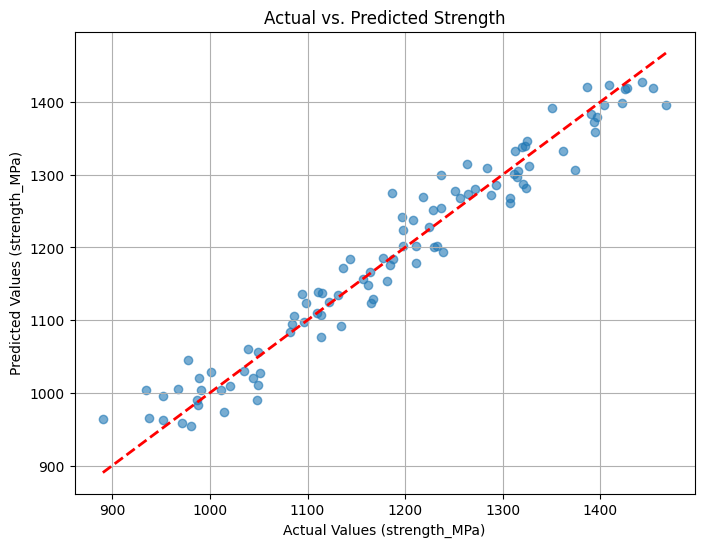

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel("Actual Values (strength_MPa)")
plt.ylabel("Predicted Values (strength_MPa)")
plt.title("Actual vs. Predicted Strength")
plt.grid(True)
plt.show()